# PokeAPI Analytics — Parte 1

Pipeline batch em camadas medallion (bronze → silver → gold) sobre a PokeAPI. Este
notebook é a camada de **orquestração e narrativa**: importa as funções já
implementadas e testadas em `src/` (`ingest`, `transform`, `quality`, `analysis`) e
não reimplementa nenhuma lógica — a lógica em si vive nos módulos, com sua própria
suíte de testes (ver `docs/IMPLEMENTATION.md`).

**Objetivo:** coletar o detalhe de todos os pokémons da PokeAPI, modelar 4 tabelas
silver com schema explícito, validar a qualidade dos dados e responder 3 perguntas
sobre o dataset.

**Ambiente:** PySpark "vanilla" — sem `display`/`dbutils`/APIs exclusivas de
Databricks (ADR-0015). Roda em Docker local, Google Colab ou Databricks sem
alterações.

**Modelo de dados** (detalhe e diagrama ERD em
[`docs/ARCHITECTURE.md`](../docs/ARCHITECTURE.md)):

- `pokemon(pokemon_id, name, height, weight, base_experience)`
- `pokemon_type(pokemon_id, type_name)`
- `pokemon_stats(pokemon_id, stat_name, base_stat)`
- `pokemon_ability(pokemon_id, ability_name, is_hidden)`

In [1]:
import sys
import time
from pathlib import Path

# Garante que `src` é importável tanto rodando a partir da raiz do projeto (Docker/CI)
# quanto de um ambiente Jupyter/Colab que clonou o repositório.
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from src import ingest, transform, quality, analysis

In [2]:
spark = (
    SparkSession.builder.appName("part1-pokeapi-analytics-notebook")
    .master("local[*]")
    .getOrCreate()
)
spark

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/08 21:45:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1. Ingestão (bronze)

Coleta assíncrona com concorrência limitada e cache em disco por id (`ADR-0006`).
O cache bronze (`data/bronze/{id}.json`) torna reruns rápidos — se os arquivos já
existem, `fetch_all` não bate na API de novo.

Por padrão rodamos com o **dataset completo** (todos os pokémons da PokeAPI, para
as respostas reais). Para uma iteração rápida em desenvolvimento, basta trocar
`MAX_ITEMS` para um inteiro pequeno (ex.: `50`) — vira um smoke test.

In [3]:
MAX_ITEMS = None  # None = dataset completo; um int (ex.: 50) faz um smoke test rápido

t0 = time.time()
index = ingest.fetch_index(max_items=MAX_ITEMS)
urls = [entry["url"] for entry in index]
details = ingest.fetch_all(urls, concurrency=10, cache_dir="data/bronze")
print(f"Coletados {len(details)} pokémons em {time.time() - t0:.1f}s (cache bronze acelera reruns)")

Coletados 1351 pokémons em 19.1s (cache bronze acelera reruns)


## 2. Transformação (silver)

As 4 tabelas com `StructType` explícito (sem `inferSchema`, `ADR-0007`) e gravadas
em Parquet.

In [4]:
pokemon_df = transform.build_pokemon(details)
pokemon_type_df = transform.build_pokemon_type(details)
pokemon_stats_df = transform.build_pokemon_stats(details)
pokemon_ability_df = transform.build_pokemon_ability(details)

transform.write_silver(pokemon_df, "pokemon")
transform.write_silver(pokemon_type_df, "pokemon_type")
transform.write_silver(pokemon_stats_df, "pokemon_stats")
transform.write_silver(pokemon_ability_df, "pokemon_ability")

print(f"pokemon:         {pokemon_df.count():>5} linhas")
print(f"pokemon_type:    {pokemon_type_df.count():>5} linhas")
print(f"pokemon_stats:   {pokemon_stats_df.count():>5} linhas")
print(f"pokemon_ability: {pokemon_ability_df.count():>5} linhas")

26/09/08 21:46:13 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.

26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 50.67% for 15 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 54.29% for 14 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/08 21:46:23 WARN MemoryManager: Total allocation exceeds 9

26/09/08 21:46:28 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


26/09/08 21:46:33 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/08 21:46:33 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/08 21:46:34 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/08 21:46:34 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/08 21:46:34 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/08 21:46:34 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/08 21:46:34 WARN MemoryManager: Total allocation exceeds 95.00

26/09/08 21:46:38 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


pokemon:          1351 linhas


pokemon_type:     2116 linhas


pokemon_stats:    8106 linhas


pokemon_ability:  2941 linhas


## 3. Qualidade (portão silver → gold)

`run_quality_report` imprime o relatório e levanta `DataQualityError` (fail loud)
se uma invariante crítica for violada — PK nula/duplicada em `pokemon`, ou órfãos
em `pokemon_type`/`pokemon_stats`/`pokemon_ability`. Se esta célula levantar, é
para o notebook parar aqui: a camada gold nunca deve ser gerada a partir de um
silver inconsistente.

In [5]:
quality.run_quality_report(
    {
        "pokemon": pokemon_df,
        "pokemon_type": pokemon_type_df,
        "pokemon_stats": pokemon_stats_df,
        "pokemon_ability": pokemon_ability_df,
    }
)

RELATÓRIO DE QUALIDADE — silver
[PASS] [CRÍTICO] not_null(pokemon_id): pokemon_id=0 nulos
[PASS] [CRÍTICO] unique(pokemon_id): 0 chave(s) duplicada(s)
[PASS] unique(pokemon_id, type_name): 0 chave(s) duplicada(s)
[PASS] [CRÍTICO] referential(pokemon_id): 0 órfão(s)
[PASS] [CRÍTICO] referential(pokemon_id): 0 órfão(s)
[PASS] [CRÍTICO] referential(pokemon_id): 0 órfão(s)


## 4. Análises (gold)

### Pergunta 1 — Multi-tipo e força acima da média

> Quantos pokémons têm mais de um tipo **e** força (soma de todos os `base_stat`)
> acima da média geral?

**Pegadinha:** "média geral da força" é a média das forças **por pokémon**
(`avg(forca)`, uma linha por pokémon) — não a média linha-a-linha de `base_stat`
(que teria uma linha por combinação pokémon×stat e pesaria errado quem tem mais
stats registrados). `q1_multitype_above_avg` calcula a média sobre o DataFrame já
agregado por pokémon (ver `docs/IMPLEMENTATION.md`, Seção 4).

In [6]:
resultado_q1, detalhe_q1 = analysis.q1_multitype_above_avg(
    pokemon_df, pokemon_type_df, pokemon_stats_df
)

print(f"Resposta Q1: {resultado_q1} pokémons são multi-tipo E têm força acima da média.\n")
detalhe_q1.orderBy(F.col("forca").desc()).show(30, truncate=False)

Resposta Q1: 510 pokémons são multi-tipo E têm força acima da média.



+----------+----------------------+-----+-------+
|pokemon_id|name                  |forca|n_types|
+----------+----------------------+-----+-------+
|10190     |eternatus-eternamax   |1125 |2      |
|10043     |mewtwo-mega-x         |780  |2      |
|10079     |rayquaza-mega         |780  |2      |
|10301     |zygarde-mega          |778  |2      |
|10078     |groudon-primal        |770  |2      |
|10157     |necrozma-ultra        |754  |2      |
|10120     |zygarde-complete      |708  |2      |
|10189     |zamazenta-crowned     |700  |2      |
|10076     |metagross-mega        |700  |2      |
|10089     |salamence-mega        |700  |2      |
|10188     |zacian-crowned        |700  |2      |
|10023     |kyurem-white          |700  |2      |
|10062     |latias-mega           |700  |2      |
|10317     |magearna-mega         |700  |2      |
|10325     |baxcalibur-mega       |700  |2      |
|10318     |magearna-original-mega|700  |2      |
|10311     |heatran-mega          |700  |2      |


### Pergunta 2 — Abilities exclusivas de multi-tipo

> Quais abilities **nunca** aparecem em nenhum pokémon de tipo único?

**Lógica:** todas as abilities distintas **menos** as que aparecem em algum
pokémon mono-tipo (`distinct().subtract(...)`) — não é "aparece em algum
multi-tipo" (isso deixaria passar abilities que também aparecem em mono-tipo).
Como toda ability vem de algum pokémon, o que sobra do `subtract` só pode vir de
pokémons multi-tipo.

In [7]:
q2_df = analysis.q2_abilities_exclusive_multitype(pokemon_type_df, pokemon_ability_df)
q2_abilities = sorted(row.ability_name for row in q2_df.collect())

print(f"Resposta Q2: {len(q2_abilities)} abilities exclusivas de multi-tipo.\n")
for name in q2_abilities:
    print(f"  - {name}")

Resposta Q2: 94 abilities exclusivas de multi-tipo.

  - aerilate
  - air-lock
  - armor-tail
  - as-one-glastrier
  - as-one-spectrier
  - aura-break
  - aura-guard
  - battery
  - battle-bond
  - beads-of-ruin
  - berserk
  - commander
  - corrosion
  - costar
  - curious-medicine
  - dancer
  - dark-aura
  - dazzling
  - defeatist
  - delta-stream
  - desolate-land
  - disguise
  - dragonize
  - dry-skin
  - emergency-exit
  - fire-mane
  - flare-boost
  - full-metal-body
  - gale-wings
  - galvanize
  - good-as-gold
  - gulp-missile
  - hadron-engine
  - harvest
  - hospitality
  - hunger-switch
  - ice-scales
  - iron-barbs
  - long-reach
  - mega-sol
  - merciless
  - mimicry
  - minds-eye
  - mirror-armor
  - misty-surge
  - multiscale
  - mycelium-might
  - neuroforce
  - orichalcum-pulse
  - piercing-drill
  - poison-puppeteer
  - power-construct
  - power-of-alchemy
  - protosynthesis
  - psychic-surge
  - punk-rock
  - pure-power
  - quark-drive
  - quick-draw
  - ripen
  - 

### Pergunta 3 — Top 5 versatilidade

> `versatility_score = (nº tipos × 2) + (nº abilities) + (soma dos stats / 100)`

`nº abilities` conta todas as habilidades distintas, incluindo as com
`is_hidden=true`. Empates são resolvidos por `pokemon_id` ascendente — sem essa
chave de desempate, a ordem entre pokémons empatados na fronteira do top 5 não
seria determinística.

In [8]:
top5_df = analysis.q3_top5_versatility(
    pokemon_df, pokemon_type_df, pokemon_stats_df, pokemon_ability_df
)
top5_rows = top5_df.orderBy(
    F.col("versatility_score").desc(), F.col("pokemon_id").asc()
).collect()

print("Resposta Q3 — Top 5 versatilidade:\n")
for rank, row in enumerate(top5_rows, start=1):
    print(f"  {rank}. {row.name} (id={row.pokemon_id}) — score={row.versatility_score:.2f}")

26/09/08 21:47:06 WARN CacheManager: Asked to cache already cached data.


Resposta Q3 — Top 5 versatilidade:

  1. eternatus-eternamax (id=10190) — score=16.25
  2. kommo-o (id=784) — score=13.00
  3. dragapult (id=887) — score=13.00
  4. archaludon (id=1018) — score=13.00
  5. kommo-o-totem (id=10146) — score=13.00


## 5. Visualização

### Top 5 versatilidade (Q3)

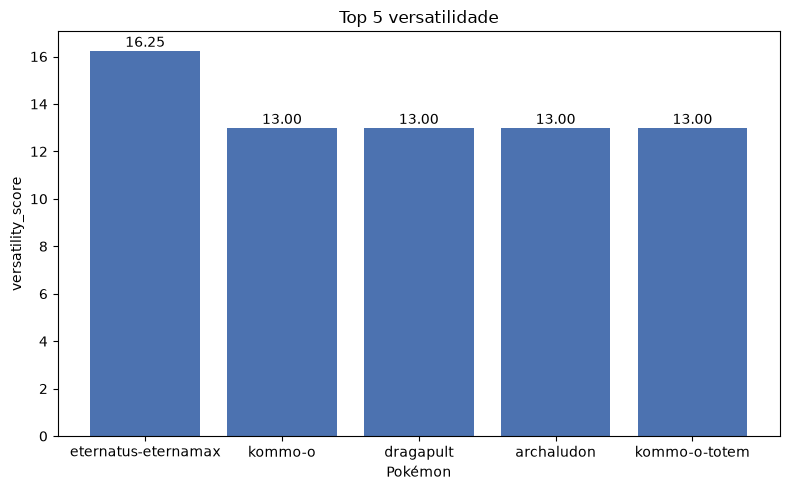

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

names = [row.name for row in top5_rows]
scores = [row.versatility_score for row in top5_rows]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(names, scores, color="#4C72B0")
ax.set_title("Top 5 versatilidade")
ax.set_xlabel("Pokémon")
ax.set_ylabel("versatility_score")
for i, v in enumerate(scores):
    ax.text(i, v + max(scores) * 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

### Distribuição da força (Q1)

Reforça visualmente a pegadinha da Pergunta 1: a linha tracejada é a média das
forças **por pokémon** (a mesma usada no filtro de Q1), não uma média sobre as
linhas de `pokemon_stats`.

26/09/08 21:47:11 WARN CacheManager: Asked to cache already cached data.


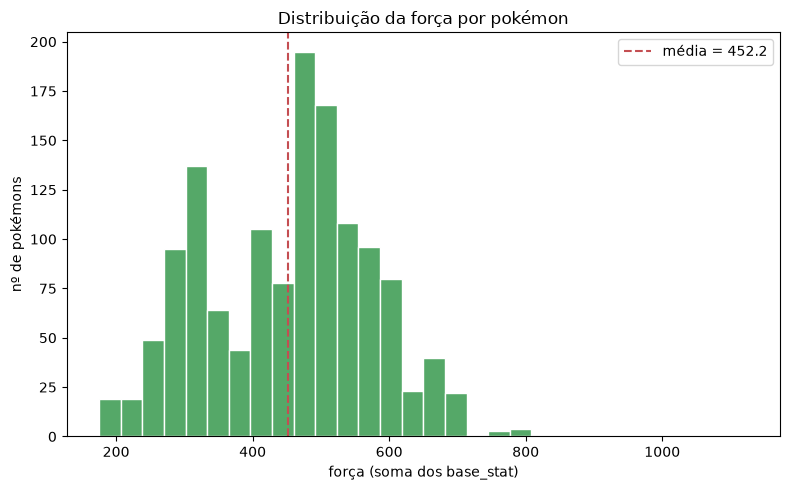

In [10]:
forca_values = [row.forca for row in analysis.forca(pokemon_stats_df).collect()]
media_forca = sum(forca_values) / len(forca_values)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(forca_values, bins=30, color="#55A868", edgecolor="white")
ax.axvline(media_forca, color="#C44E52", linestyle="--", label=f"média = {media_forca:.1f}")
ax.set_title("Distribuição da força por pokémon")
ax.set_xlabel("força (soma dos base_stat)")
ax.set_ylabel("nº de pokémons")
ax.legend()
plt.tight_layout()
plt.show()

## Conclusão

As 3 respostas acima vêm direto das funções de `src/analysis.py`, sobre as 4
tabelas silver geradas por `src/transform.py` e validadas por
`src/quality.py` — nenhuma lógica foi reimplementada aqui. Detalhe de
implementação, tradeoffs e estratégia de testes de cada módulo (incluindo a
pegadinha da média e a lógica do `subtract` de Q2) estão documentados em
[`docs/IMPLEMENTATION.md`](docs/IMPLEMENTATION.md).